<a href="https://colab.research.google.com/github/faisu6339-glitch/Machine-learning/blob/main/Decision_Tree(Part_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A decision tree is a supervised machine learning algorithm that can be used for both classification and regression tasks. It's a non-parametric model, meaning it makes no explicit assumptions about the underlying distribution of the data.

### How it Works

Imagine a flowchart. A decision tree works in a very similar way. It starts with a **root node**, which represents the entire dataset. From this root, it splits the data into two or more homogeneous sets based on a feature (or attribute) that best separates the data. This splitting process continues recursively until a stopping criterion is met (e.g., a certain depth is reached, no significant information gain is observed, or a minimum number of samples per leaf is met).

Each internal node in the tree represents a "test" on an attribute (e.g., "Is age > 30?"). Each branch represents the outcome of the test (e.g., "Yes" or "No"). And each **leaf node** represents a class label (in classification) or a predicted value (in regression).

### Key Concepts

1.  **Nodes:**
    *   **Root Node:** The topmost node in the tree, representing the initial dataset.
    *   **Internal Node (Decision Node):** A node that splits into two or more branches, based on a decision rule.
    *   **Leaf Node (Terminal Node):** A node that does not split further. It provides the final prediction or classification.

2.  **Splitting Criteria:** The algorithm decides how to split the data at each node based on certain metrics. The goal is to maximize the homogeneity (purity) of the child nodes.
    *   **For Classification (e.g., ID3, C4.5, CART):**
        *   **Information Gain (ID3, C4.5):** Measures the reduction in entropy (a measure of impurity) after splitting a dataset based on an attribute. The attribute with the highest information gain is chosen for splitting.
        *   **Gini Impurity (CART):** Measures the probability of incorrectly classifying a randomly chosen element in the dataset if it were randomly labeled according to the distribution of class labels in the dataset. A lower Gini impurity is better.
    *   **For Regression (e.g., CART):**
        *   **Mean Squared Error (MSE) / Variance Reduction:** The algorithm tries to minimize the variance within each child node after a split. The split that results in the greatest reduction in variance is chosen.

3.  **Pruning:** Decision trees can easily overfit the training data, meaning they become too complex and capture noise. Pruning is a technique used to reduce the size of the tree by removing branches that have low predictive power.
    *   **Pre-pruning:** Stopping the tree construction early (e.g., limiting max depth, min samples per leaf).
    *   **Post-pruning:** Growing a full tree first and then removing branches (e.g., using cost-complexity pruning).

### Advantages

*   **Easy to Understand and Interpret:** The tree structure is intuitive and can be easily visualized.
*   **Handles Both Numerical and Categorical Data:** Can be used for various data types.
*   **Little Data Preparation Needed:** Less pre-processing like normalization or scaling is required compared to some other algorithms.
*   **Can Model Non-Linear Relationships:** Capable of capturing complex patterns.

### Disadvantages

*   **Prone to Overfitting:** Without proper pruning, decision trees can become very complex and perform poorly on unseen data.
*   **Instability:** Small variations in the data can lead to a completely different tree structure.
*   **Bias Towards Dominant Classes:** Can be biased towards classes with more samples.
*   **Cannot Guarantee Optimal Tree:** Finding the globally optimal decision tree is an NP-complete problem, so greedy algorithms are often used, which don't always find the best tree.

### Applications

Decision trees are widely used in various fields, including:

*   **Medical Diagnosis:** Identifying diseases based on symptoms.
*   **Credit Scoring:** Assessing creditworthiness of applicants.
*   **Fraud Detection:** Identifying fraudulent transactions.
*   **Customer Relationship Management (CRM):** Predicting customer churn or identifying target customers.

In summary, decision trees are powerful and intuitive models, especially when interpretability is important. However, their tendency to overfit often leads to their use as components within ensemble methods like Random Forests or Gradient Boosting, which combine multiple trees to improve accuracy and stability.

Overfitting is a common problem in machine learning, and decision trees are particularly susceptible to it. Here's a detailed explanation:

### What is Overfitting?

Overfitting occurs when a machine learning model learns the training data too well, including the noise and random fluctuations present in the data, rather than learning the underlying patterns. As a result, the model performs very well on the training data but poorly on unseen or new data.

Imagine you're studying for a test by memorizing every single question and answer from a practice exam. You might ace that specific practice exam, but if the actual test has slightly different questions or phrasing, you might perform poorly because you didn't learn the general concepts, only the specific answers.

### Why are Decision Trees Prone to Overfitting?

Decision trees, by their nature, can grow very deep and complex. If left unchecked, a decision tree can create a unique path for every single data point in the training set, essentially memorizing the training data. Here's why:

1.  **Greedy Approach:** Decision tree algorithms (like CART) use a greedy approach, making the best split at each node without considering the overall impact on future splits or the tree's complexity. This can lead to very specific and deep branches that cater to individual data points.
2.  **Lack of Constraints:** Without specific parameters to limit their growth (like maximum depth, minimum samples per leaf, or minimum impurity decrease), decision trees will continue to split nodes until each leaf node contains a single class (in classification) or a very small, homogeneous set of values (in regression). This creates a highly complex model that perfectly fits the training data but captures noise rather than generalizable patterns.
3.  **High Variance:** Overfitted decision trees tend to have high variance, meaning small changes in the training data can lead to a drastically different tree structure, making them unstable and unreliable on new data.

### How to Detect Overfitting

*   **Performance on Training vs. Test Set:** The most common way to detect overfitting is by comparing the model's performance on the training data versus a separate validation or test set. An overfitted model will have very high accuracy (or low error) on the training set but significantly lower accuracy (or higher error) on the test set.
*   **Complex Tree Structure:** Visually inspecting the tree structure (if possible) and noting very deep or bushy trees can be an indicator.

### Strategies to Mitigate Overfitting in Decision Trees

Several techniques can be used to combat overfitting in decision trees:

1.  **Pruning:**
    *   **Pre-pruning (or Early Stopping):** This involves stopping the tree's growth before it becomes fully fitted to the training data. Common pre-pruning parameters include:
        *   `max_depth`: Limits the maximum depth of the tree.
        *   `min_samples_split`: The minimum number of samples required to split an internal node.
        *   `min_samples_leaf`: The minimum number of samples required to be at a leaf node.
        *   `max_features`: The number of features to consider when looking for the best split.
        *   `min_impurity_decrease`: A node will be split if this split induces a decrease of the impurity greater than or equal to this value.
    *   **Post-pruning (or Cost-Complexity Pruning / Weakest Link Pruning):** This involves growing a full decision tree and then pruning back branches from the tree. It uses a cost-complexity parameter (alpha) to penalize complexity. Scikit-learn's `ccp_alpha` parameter is an example of this.

2.  **Ensemble Methods:** These are powerful techniques that combine multiple decision trees to improve overall performance and reduce overfitting.
    *   **Random Forests:** Builds multiple decision trees on different subsets of the data and features, and then averages their predictions (for regression) or uses majority voting (for classification). This reduces variance and overfitting.
    *   **Gradient Boosting (e.g., AdaBoost, XGBoost, LightGBM):** Builds trees sequentially, where each new tree tries to correct the errors of the previous ones. These methods are very powerful but can also overfit if not properly tuned.

3.  **Cross-Validation:** Using techniques like k-fold cross-validation helps in getting a more reliable estimate of the model's performance on unseen data and can guide the tuning of pruning parameters.

By carefully applying these techniques, you can build decision trees that generalize well to new data and avoid the pitfalls of overfitting.

#Program 1

In [15]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

# Sample dataset
data = {
    'Age': [25, 30, 45, 35, 22, 40],
    'Salary': [30000, 40000, 80000, 60000, 20000, 70000],
    'Buy': ['No', 'No', 'Yes', 'Yes', 'No', 'Yes']
}

df = pd.DataFrame(data)

# Convert target to numeric
df['Buy'] = df['Buy'].map({'No': 0, 'Yes': 1})

X = df[['Age', 'Salary']]
y = df['Buy']

# Model
dt = DecisionTreeClassifier()
dt.fit(X, y)

# Prediction
print(dt.predict([[28, 50000]]))  # Example input


[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [16]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load data
iris = load_iris()
X = iris.data
y = iris.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

# Prediction
y_pred = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9333333333333333


In [17]:
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
print("Accuracy with max_depth=3:", accuracy_score(y_test, y_pred))


Accuracy with max_depth=3: 0.9333333333333333


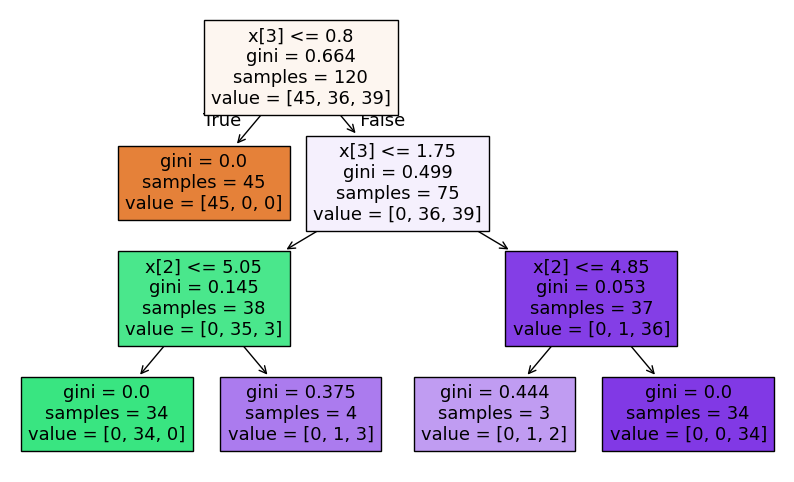

In [18]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(10,6))
plot_tree(dt, filled=True)
plt.show()


In [19]:
import pandas as pd

importance = pd.Series(dt.feature_importances_)
print(importance)


0    0.00000
1    0.00000
2    0.06039
3    0.93961
dtype: float64


In [20]:
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# Data
X, y = make_regression(n_samples=100, n_features=1, noise=10)

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y)

# Model
dtr = DecisionTreeRegressor(max_depth=3)
dtr.fit(X_train, y_train)

# Prediction
y_pred = dtr.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))


R2 Score: 0.5450153477636073


#Program 2

#Decision Tree – Basic Classification

In [10]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_iris()
X_iris = data.data
y_iris = data.target

# Split Iris dataset for classification
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

# Model
dt = DecisionTreeClassifier()
dt.fit(X_train_iris, y_train_iris)

# Prediction
y_pred_iris = dt.predict(X_test_iris)

print("Accuracy:", accuracy_score(y_test_iris, y_pred_iris))

Accuracy: 1.0


#Decision Tree – Visualization

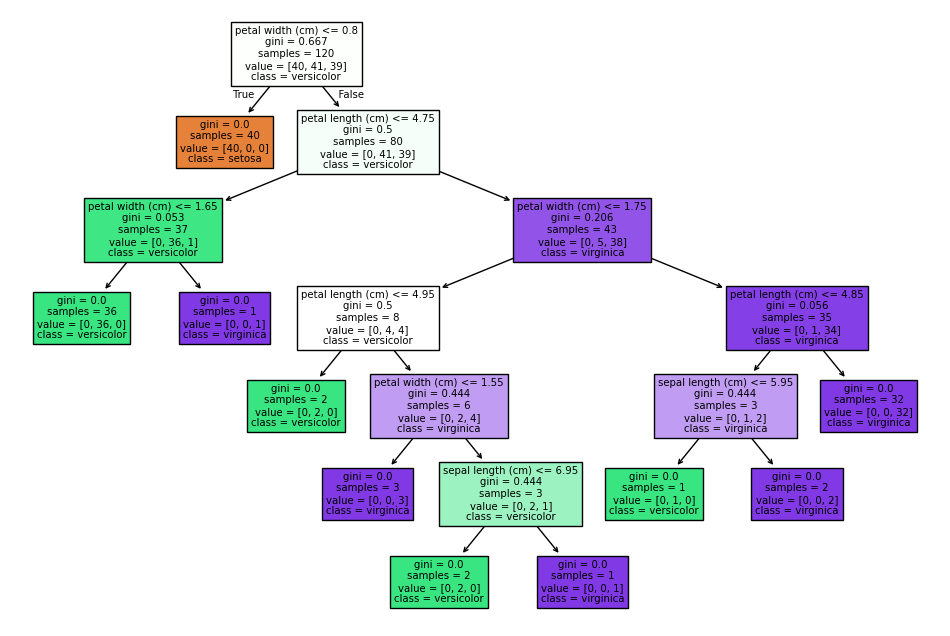

In [2]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(dt, feature_names=data.feature_names, class_names=data.target_names, filled=True)
plt.show()


#Decision Tree with Depth Control (Avoid Overfitting)

In [11]:
dt_depth = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_depth.fit(X_train_iris, y_train_iris)

y_pred_depth = dt_depth.predict(X_test_iris)
print("Accuracy with max_depth=3:", accuracy_score(y_test_iris, y_pred_depth))

Accuracy with max_depth=3: 1.0


#Decision Tree – Regression

In [4]:
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# Dataset
X, y = make_regression(n_samples=200, n_features=1, noise=10, random_state=42)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
dtr = DecisionTreeRegressor(max_depth=4)
dtr.fit(X_train, y_train)

# Prediction
y_pred = dtr.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))


R2 Score: 0.9620108983137814


In [5]:
DecisionTreeClassifier(criterion='gini')


DecisionTreeClassifier()

In [12]:
dt_entropy = DecisionTreeClassifier(criterion='entropy')
dt_entropy.fit(X_train_iris, y_train_iris)

DecisionTreeClassifier(criterion='entropy')

In [7]:
DecisionTreeClassifier(criterion='log_loss')


DecisionTreeClassifier(criterion='log_loss')

#Feature Importance

In [8]:
import pandas as pd

feature_importance = pd.Series(dt.feature_importances_, index=data.feature_names)
print(feature_importance.sort_values(ascending=False))


petal width (cm)     0.577395
petal length (cm)    0.389265
sepal length (cm)    0.033340
sepal width (cm)     0.000000
dtype: float64


#Decision Tree with GridSearch (Hyperparameter Tuning)

In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [2,3,4,5],
    'min_samples_split': [2,5,10]
}

grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid.fit(X_train_iris, y_train_iris)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 4, 'min_samples_split': 2}


#Decision Boundary Plot (2 Features)

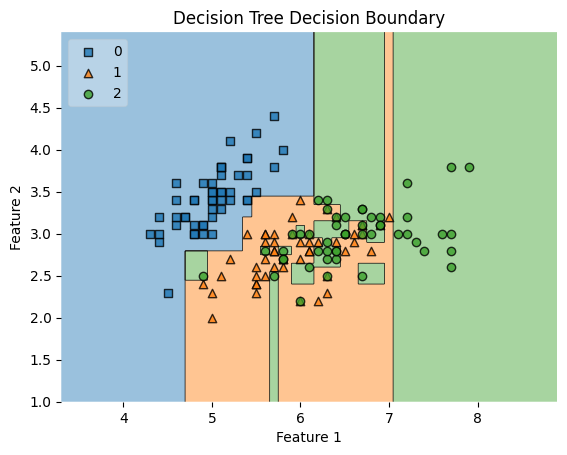

In [14]:
from mlxtend.plotting import plot_decision_regions
import numpy as np

# Use only 2 features
X2 = data.data[:, :2]
y2 = data.target

dt2 = DecisionTreeClassifier()
dt2.fit(X2, y2)

plot_decision_regions(X=X2, y=y2, clf=dt2, legend=2)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Tree Decision Boundary')
plt.show()
